# Basic comparsion of naive and fast convolution

In [187]:
import numpy as np
import sympy as sy
from PIL import Image
from scipy import signal
from scipy import datasets
from matplotlib import pyplot as plt
from sympy import Matrix as M

In [188]:
from fast_convolution.naive import naive_convolve
from fast_convolution.fast import toomcook_conv1d, toom_cook, g_to_bg
from fast_convolution.utils import plot_pdf, symmetrical_cyclic_convolution

from fast_convolution import fast

In [189]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

Lets do a really basic test to compare naive with fast convolution
The input feature will be a simple 5x5 matrix and the output will be a 3x3 matrix

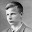

In [190]:
image = Image.open('../images/karatsuba032.jpg')
image

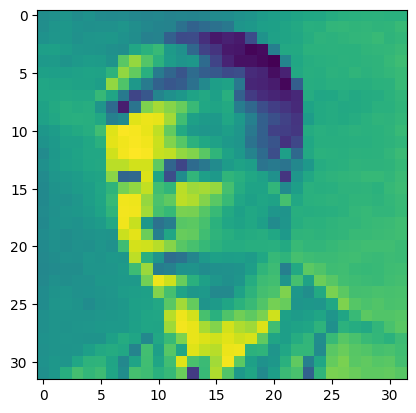

In [191]:
plt.imshow(image)

In [192]:
feature = np.array(image)
feature.shape

In [193]:
# Laplace discrete operator
weight = np.array([
    [ 0, 1, 0],
    [ 1, -4, 1],
    [ 0, 1, 0],
])
weight

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

Convolution with no paddin and stride 1
Using convolve2d from scipy, our gold method, it's necessary to reverse the weights to get same result of naive and fast convolution

In [194]:
wr = weight[::-1, ::-1]
wr

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

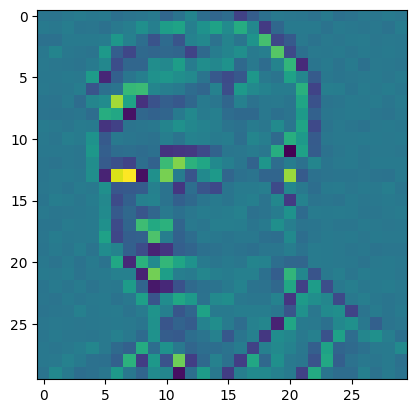

In [195]:
output = signal.convolve2d(feature, wr, mode='valid')
plt.imshow(output)

Running naive convolution
9 multiplications and 8 aditions per output scalar

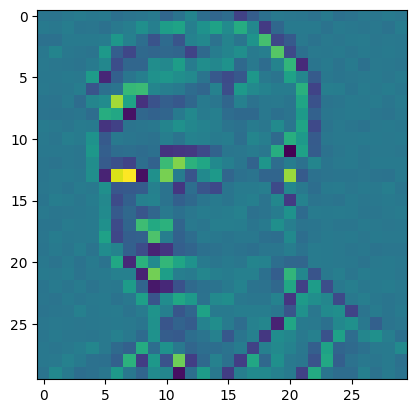

In [196]:
output_naive = naive_convolve(feature, weight)
plt.imshow(output_naive)

In [197]:
np.all(output == output_naive)

True

Fast convolution need to reverse the features order

Init Tap filter from fast 1d convolution method with 5 multiplications, 20 aditions and 9 extras operations, 5 input and 3 output per batch

The tap filter work in batch mode and the output is reversed

In [198]:
c0 = np.convolve(feature[0], weight[0], mode='valid')
c0

array([120, 124, 118, 122, 116, 115, 116, 111, 109, 111, 107, 109, 108,
       110, 116, 117, 121, 124, 132, 135, 136, 140, 143, 144, 148, 151,
       152, 153, 154, 152])

In [199]:
c1 = np.convolve(feature[1], weight[1], mode='valid')
c1

array([-254, -261, -241, -237, -243, -238, -260, -239, -221, -213, -230,
       -177, -130, -170, -180, -169, -276, -252, -276, -269, -279, -289,
       -309, -291, -323, -321, -311, -319, -309, -311])

In [200]:
c2 = np.convolve(feature[2], weight[2], mode='valid')
c2

array([126, 127, 121, 125, 126, 127, 122, 118, 106, 107,  74,  55,  56,
        33,  16,  23,  18,  57, 123, 137, 140, 144, 149, 155, 154, 156,
       158, 159, 161, 156])

In [201]:
points = [0, -1, 1, -2, np.inf]
points

In [202]:
fast_conv = [toomcook_conv1d(3, 3, points, weight[i]) for i in range(3)]

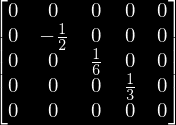

In [226]:
c, q, b, a = fast.toom_cook(3, 3, points)
g_to_bg(q, b, weight[0])

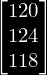

In [203]:
out0 = fast_conv[0](feature[0, :5])
out0

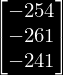

In [204]:
out1 = fast_conv[1](feature[1, :5])
out1

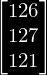

In [205]:
out2 = fast_conv[2](feature[2, :5])
out2

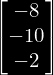

In [206]:
out0 + out1 + out2

In [207]:
output[0, :3]

array([ -8, -10,  -2])

In [208]:
pad = 0


How join multiple 1d convolution in one 2d convolution

Sum results in the first dimension

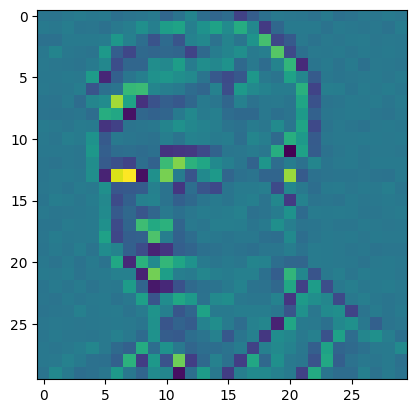

In [209]:
output_fast = np.sum([fast.filter1d_slide2d(fast_conv[i], feature, output.shape, i, 5, 3) for i in range(0, 3)], axis=0)
plt.imshow(output_fast)

In [210]:
np.all(output_fast == output_naive)

True

In [233]:
output_naive

array([[  -8,  -10,   -2,   10,   -1,    4,  -22,  -10,   -6,    5,  -49,
         -13,   34,  -27,  -48,  -29, -137,  -71,  -21,    3,   -3,   -5,
         -17,    8,  -21,  -14,   -1,   -7,    6,   -3],
       [   6,   -1,   16,   -8,   -7,  -19,    1,   17,   66,   21,  104,
         121,   21,   72,  119,   55,  148,   45, -155,  -45,    6,    4,
           7,  -14,    7,    0,   -7,   -2,  -15,   12],
       [ -19,  -19,    5,    8,    7,   13,   86,   23,  -28,  -99,  -35,
         -93,   28,   43,  -17,   32,   -9,   76,  206, -125,  -81,    1,
         -15,    1,   -4,    5,    9,   -3,    1,    0],
       [   0,   33,    0,   -6,  -10,   93,  -69, -127,  -41,  -47,  -43,
         -51, -134,  -39,   13,   33,   62,    5,   19,  226, -123,  -23,
           1,   -1,    5,   -6,    7,    0,    5,   -1],
       [   2,   -4,   -6,  -10,    8,   41, -112,  -48,  -47,   61,   43,
         104,   13,   61,   42,   72,  -40,    3,  -32,   30,  173, -191,
          -8,    7,  -12,    8, 

In [263]:
t = fast.filter1d_slide2d(fast_conv[0], feature, output.shape, 0, 5, 3).reshape(-1)

In [265]:
tt = np.array([
    120, 124, 118, 122, 116, 115, 116, 111, 109, 111, 107, 109, 108, 110, 116, 117, 121, 124, 132, 135, 136, 140, 143, 144, 148, 151, 152, 153, 154, 152, 125, 127, 122, 120, 121, 121, 125, 119, 112, 108, 107, 90, 76, 84, 90, 96, 125, 128, 135, 136, 140, 145, 151, 150, 158, 159, 157, 158, 156, 157, 126, 127, 121, 125, 126, 127, 122, 118, 106, 107, 74, 55, 56, 33, 16, 23, 18, 57, 123, 137, 140, 144, 149, 155, 154, 156, 158, 159, 161, 156, 136, 133, 126, 125, 124, 120, 119, 142, 153, 161, 131, 121, 81, 48, 37, 17, 15, 4, 8, 104, 145, 146, 153, 153, 154, 153, 153, 157, 158, 159, 131, 124, 130, 133, 132, 123, 178, 201, 175, 154, 133, 124, 127, 84, 50, 25, 12, 12, 7, 1, 109, 143, 149, 151, 152, 154, 153, 155, 156, 160, 135, 135, 137, 139, 138, 155, 200, 182, 151, 100, 80, 64, 85, 72, 67, 54, 58, 30, 26, 10, 24, 145, 150, 149, 154, 152, 157, 154, 156, 159, 140, 140, 138, 138, 134, 200, 173, 128, 100, 76, 66, 71, 90, 113, 134, 138, 96, 27, 25, 19, 5, 72, 149, 148, 151, 151, 150, 150, 153, 154, 143, 145, 144, 144, 160, 141, 99, 51, 66, 108, 120, 127, 139, 145, 136, 151, 75, 42, 31, 26, 21, 28, 148, 142, 143, 148, 145, 147, 148, 153, 146, 150, 147, 149, 125, 84, 20, 93, 193, 207, 196, 184, 162, 143, 140, 146, 102, 81, 58, 45, 38, 29, 139, 146, 147, 145, 146, 147, 152, 152, 144, 150, 151, 150, 144, 105, 114, 228, 232, 230, 206, 166, 136, 131, 130, 142, 129, 105, 74, 59, 48, 38, 133, 146, 147, 146, 148, 152, 156, 155, 133, 141, 146, 149, 166, 227, 238, 236, 231, 216, 182, 146, 130, 126, 127, 134, 126, 97, 74, 47, 45, 40, 147, 151, 149, 151, 154, 152, 153, 156, 130, 137, 137, 143, 152, 229, 234, 237, 234, 220, 194, 176, 154, 143, 137, 130, 125, 92, 74, 63, 36, 52, 143, 150, 150, 150, 151, 151, 153, 155, 128, 135, 139, 144, 144, 222, 235, 239, 237, 219, 216, 200, 194, 178, 157, 138, 128, 107, 84, 58, 135, 82, 145, 153, 152, 151, 154, 153, 154, 158, 129, 136, 138, 143, 145, 214, 214, 223, 223, 180, 79, 51, 84, 96, 116, 132, 138, 134, 93, 99, 93, 112, 128, 148, 151, 152, 156, 155, 155, 156, 126, 130, 133, 138, 140, 198, 79, 81, 226, 140, 57, 117, 158, 135, 129, 157, 151, 143, 137, 121, 38, 126, 144, 152, 155, 157, 158, 160, 160, 158, 123, 126, 132, 134, 142, 156, 189, 200, 217, 166, 158, 214, 204, 207, 201, 169, 148, 139, 139, 158, 115, 134, 152, 150, 151, 155, 155, 156, 153, 160, 122, 121, 126, 134, 141, 161, 234, 233, 201, 172, 180, 215, 211, 195, 178, 161, 142, 136, 141, 138, 169, 144, 152, 153, 155, 154, 157, 157, 155, 159, 121, 125, 127, 132, 139, 157, 235, 234, 206, 169, 160, 191, 190, 176, 161, 146, 136, 143, 139, 126, 124, 150, 149, 150, 151, 154, 159, 160, 158, 158, 122, 124, 122, 127, 132, 145, 234, 219, 127, 91, 102, 177, 179, 170, 153, 142, 138, 143, 135, 116, 125, 149, 154, 153, 156, 158, 158, 160, 162, 163, 121, 118, 121, 123, 125, 124, 220, 229, 186, 104, 142, 184, 182, 166, 156, 150, 146, 147, 149, 143, 130, 156, 157, 155, 157, 158, 161, 161, 163, 164, 120, 118, 121, 120, 125, 121, 165, 224, 222, 213, 196, 177, 170, 160, 154, 148, 148, 150, 150, 151, 146, 161, 158, 158, 160, 163, 164, 166, 166, 166, 118, 121, 120, 126, 124, 128, 127, 215, 151, 125, 86, 92, 110, 129, 136, 134, 135, 132, 143, 160, 156, 169, 165, 163, 163, 165, 166, 163, 162, 164, 116, 118, 118, 125, 125, 126, 131, 164, 203, 102, 106, 122, 123, 117, 120, 121, 123, 134, 157, 164, 104, 145, 179, 173, 165, 166, 161, 160, 161, 165, 120, 119, 121, 121, 127, 127, 130, 129, 188, 233, 221, 184, 152, 136, 126, 120, 125, 148, 164, 167, 125, 169, 138, 186, 177, 167, 165, 163, 162, 166, 123, 125, 121, 122, 124, 126, 133, 134, 136, 194, 169, 139, 127, 129, 113, 113, 137, 155, 168, 172, 193, 127, 119, 146, 191, 179, 168, 169, 171, 170, 125, 126, 123, 117, 123, 125, 128, 136, 137, 144, 178, 206, 183, 124, 131, 141, 153, 162, 174, 189, 184, 125, 127, 126, 143, 193, 176, 172, 174, 171, 124, 124, 124, 124, 126, 127, 129, 135, 141, 142, 213, 233, 223, 170, 152, 173, 187, 180, 191, 222, 136, 132, 135, 141, 125, 141, 161, 179, 174, 174, 124, 123, 125, 126, 128, 130, 130, 136, 141, 140, 205, 235, 231, 208, 195, 223, 211, 205, 226, 166, 134, 138, 141, 155, 120, 154, 148, 145, 158, 171, 124, 125, 124, 123, 123, 136, 147, 141, 112, 144, 161, 192, 231, 226, 222, 228, 221, 225, 181, 140, 134, 148, 158, 118, 161, 177, 171, 162, 159, 153, 124, 124, 125, 135, 145, 147, 144, 107, 167, 135, 176, 142, 227, 217, 213, 232, 233, 154, 156, 125, 142, 159, 159, 116, 178, 185, 177, 174, 169, 171,
])

In [266]:
all(t == tt)

True

In [259]:
all(output_fast.reshape(-1) == tt)

False

Camparing how much operations are used in naive and fast method

Output Size

In [211]:
size = output.size
size

Naive: total of multiplications

In [212]:
size * 9

Naive: total of additions

In [213]:
size * 8

Fast: total of multiplications

In [214]:
fast_op_count = fast.filter1d_slide2d_count(output.shape, 3)
fast_op_count * 5 * len(fast_conv)

In [215]:
fast_op_count

Fast: additions for each batch processed

In [216]:
add0 =fast_op_count * 20 * len(fast_conv)
add0

Fast: additions to join batches

In [217]:
add1 = fast_op_count * 2 * len(fast_conv)
add1

Fast: Total of additions

In [218]:
add0 + add1

Fast: total of extra operations - bit shifts and etc

In [219]:
fast_op_count * 9 * len(fast_conv)